# IBM Quantum — Model B & Model C Training
## Random Forest vs XGBoost + LOBO model selection

This notebook mirrors the previous Model A methodology: the same label, the same 17 historical features, the same leakage-safe `shift(1) + expanding()` feature construction, LOBO evaluation, RF/XGBoost comparison, and selection of the best algorithm by mean LOBO AUC.

**Model B:** 2026-07-13 → 2026-07-19  
**Model C:** 2026-07-13 → 2026-08-11 (30 inclusive calendar dates)

The previous Model A notebook selected the algorithm with the higher mean LOBO AUC and then saved that model for the live layer. fileciteturn11file1L74-L84

In [1]:
import os, json, pickle, warnings
from datetime import date
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, f1_score, matthews_corrcoef, roc_curve
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = r"D:\Downloads\uday projects\ibm_quantum"
CAL_CSV = os.path.join(PROJECT_ROOT, "backup_calibration_history_20260811_1706.csv")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")

for d in [MODELS_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

MODEL_B_START, MODEL_B_END = "2026-07-13", "2026-07-19"
MODEL_C_START, MODEL_C_END = "2026-07-13", "2026-08-11"

T1_THRESH, T2_THRESH, RE_THRESH = 100.0, 50.0, 0.05

HIST_FEATURES = [
    "hist_T1_mean", "hist_T1_std", "hist_T1_min", "hist_T1_max",
    "hist_T2_mean", "hist_T2_std", "hist_T2_min", "hist_T2_max",
    "hist_RE_mean", "hist_RE_std", "hist_RE_min", "hist_RE_max",
    "prev_T1", "prev_T2", "prev_RE",
    "hist_coherence_product", "hist_t2_t1_ratio"
]

XGB_PARAMS = dict(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, eval_metric="logloss", verbosity=0
)

RF_PARAMS = dict(
    n_estimators=200, max_depth=8,
    random_state=RANDOM_STATE, n_jobs=-1
)

assert os.path.exists(CAL_CSV), f"CSV NOT FOUND: {CAL_CSV}"

print("Configuration OK")
print("CSV:", CAL_CSV)
print("Features:", len(HIST_FEATURES))


Configuration OK
CSV: D:\Downloads\uday projects\ibm_quantum\backup_calibration_history_20260811_1706.csv
Features: 17


In [2]:
def load_calibration(path):
    df = pd.read_csv(path)
    required = ["snapshot_date","backend","qubit","T1_us","T2_us","readout_error"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    df["snapshot_date"] = pd.to_datetime(df["snapshot_date"], errors="coerce")
    for c in ["T1_us","T2_us","readout_error","qubit"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=required).copy()
    df["qubit"] = df["qubit"].astype(int)
    return df.sort_values(["backend","qubit","snapshot_date"]).reset_index(drop=True)

raw = load_calibration(CAL_CSV)

print("="*65)
print("RAW DATA")
print("="*65)
print("Rows:", f"{len(raw):,}")
print("Date range:", raw.snapshot_date.min().date(), "→", raw.snapshot_date.max().date())
print("Unique dates:", raw.snapshot_date.nunique())
print("Backends:", sorted(raw.backend.unique()))
print("T1 mean:", f"{raw.T1_us.mean():.1f} μs")
assert raw.T1_us.mean() < 10000, "T1 unit sanity check failed"


RAW DATA
Rows: 13,980
Date range: 2026-07-13 → 2026-08-11
Unique dates: 30
Backends: ['ibm_fez', 'ibm_kingston', 'ibm_marrakesh']
T1 mean: 177.4 μs


In [3]:
def add_label(df):
    df = df.copy()
    df["label"] = (
        (df.T1_us > T1_THRESH) &
        (df.T2_us > T2_THRESH) &
        (df.readout_error < RE_THRESH)
    ).astype(int)
    return df

def add_hist_features(df):
    df = df.sort_values(["backend","qubit","snapshot_date"]).copy()
    df["snapshot_id"] = df.groupby(["backend","qubit"])["snapshot_date"].transform(
        lambda x: pd.factorize(x)[0]
    )
    for col, alias in [("T1_us","T1"),("T2_us","T2"),("readout_error","RE")]:
        g = df.groupby(["backend","qubit"])[col]
        df[f"hist_{alias}_mean"] = g.transform(lambda x: x.shift(1).expanding().mean())
        df[f"hist_{alias}_std"]  = g.transform(lambda x: x.shift(1).expanding().std())
        df[f"hist_{alias}_min"]  = g.transform(lambda x: x.shift(1).expanding().min())
        df[f"hist_{alias}_max"]  = g.transform(lambda x: x.shift(1).expanding().max())
        df[f"prev_{alias}"]      = g.transform(lambda x: x.shift(1))
    df["hist_coherence_product"] = df.hist_T1_mean * df.hist_T2_mean
    df["hist_t2_t1_ratio"] = df.hist_T2_mean / (df.hist_T1_mean + 1e-9)
    return df

def leakage_audit(df, name):
    snap0 = df[df.snapshot_id == 0]
    rates = snap0[HIST_FEATURES].isna().mean()
    print(f"{name}: snapshot-0 feature NaN min/max = {rates.min():.3f}/{rates.max():.3f}")
    assert (rates == 1.0).all(), f"LEAKAGE DETECTED in {name}"
    print(f"{name}: LEAKAGE AUDIT PASSED")

def build_dataset(raw_df, start, end, name):
    w = raw_df[
        (raw_df.snapshot_date >= pd.Timestamp(start)) &
        (raw_df.snapshot_date <= pd.Timestamp(end))
    ].copy()
    print("\n" + "="*65)
    print(name)
    print("="*65)
    print(f"Window: {start} → {end}")
    print("Calendar dates:", w.snapshot_date.nunique())
    print("Backends:", sorted(w.backend.unique()))
    w = add_hist_features(add_label(w))
    leakage_audit(w, name)
    m = w[w.snapshot_id >= 1].dropna(subset=HIST_FEATURES).copy()
    print("Model rows:", f"{len(m):,}")
    print("Viable rate:", f"{m.label.mean():.4f}")
    for b, s in m.groupby("backend"):
        print(f"  {b}: {len(s):,} rows | viable={s.label.mean():.4f}")
    return m

df_b = build_dataset(raw, MODEL_B_START, MODEL_B_END, "MODEL B — 7 DAY")
df_c = build_dataset(raw, MODEL_C_START, MODEL_C_END, "MODEL C — 30 DAY")



MODEL B — 7 DAY
Window: 2026-07-13 → 2026-07-19
Calendar dates: 7
Backends: ['ibm_fez', 'ibm_kingston', 'ibm_marrakesh']
MODEL B — 7 DAY: snapshot-0 feature NaN min/max = 1.000/1.000
MODEL B — 7 DAY: LEAKAGE AUDIT PASSED
Model rows: 2,330
Viable rate: 0.6292
  ibm_fez: 775 rows | viable=0.5342
  ibm_kingston: 775 rows | viable=0.7897
  ibm_marrakesh: 780 rows | viable=0.5641

MODEL C — 30 DAY
Window: 2026-07-13 → 2026-08-11
Calendar dates: 30
Backends: ['ibm_fez', 'ibm_kingston', 'ibm_marrakesh']
MODEL C — 30 DAY: snapshot-0 feature NaN min/max = 1.000/1.000
MODEL C — 30 DAY: LEAKAGE AUDIT PASSED
Model rows: 13,048
Viable rate: 0.6069
  ibm_fez: 4,340 rows | viable=0.5263
  ibm_kingston: 4,340 rows | viable=0.7512
  ibm_marrakesh: 4,368 rows | viable=0.5437


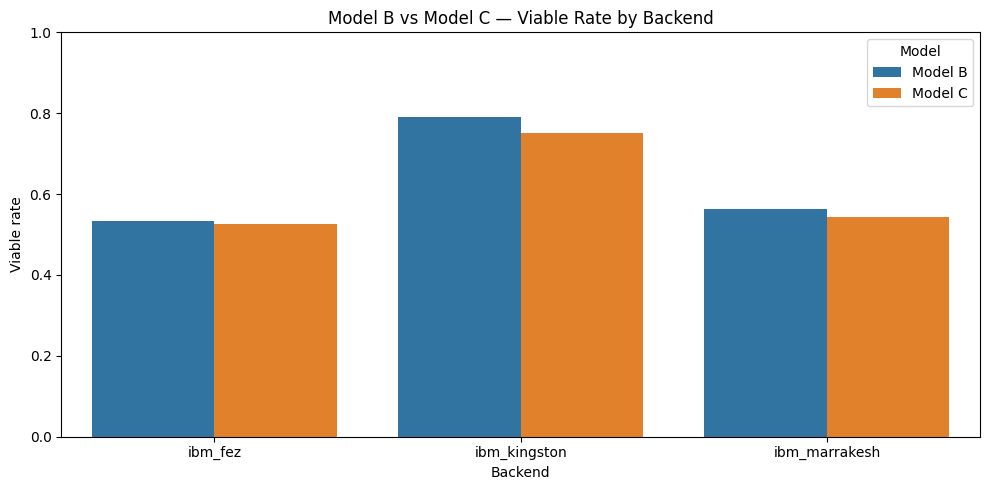

In [4]:
# Data sanity visualization
rows = []
for name, df in [("Model B", df_b), ("Model C", df_c)]:
    for b, s in df.groupby("backend"):
        rows.append({"Model":name, "Backend":b, "ViableRate":s.label.mean()})
bal = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=bal, x="Backend", y="ViableRate", hue="Model", ax=ax)
ax.set_ylim(0,1)
ax.set_ylabel("Viable rate")
ax.set_title("Model B vs Model C — Viable Rate by Backend")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,"model_b_c_data_balance.png"), dpi=150)
plt.show()


In [5]:
def run_lobo(data, model_class, params, model_name):
    rows, preds = [], {}
    for test_b in sorted(data.backend.unique()):
        tr = data[data.backend != test_b]
        te = data[data.backend == test_b]
        if te.label.nunique() < 2:
            continue

        m = model_class(**params)
        m.fit(tr[HIST_FEATURES], tr.label)

        yt = te.label.to_numpy()
        yp = m.predict_proba(te[HIST_FEATURES])[:,1]
        yc = (yp >= 0.5).astype(int)

        rows.append({
            "Model": model_name,
            "Test_Backend": test_b,
            "Train_Rows": len(tr),
            "Test_Rows": len(te),
            "AUC": roc_auc_score(yt, yp),
            "Balanced_Accuracy": balanced_accuracy_score(yt, yc),
            "F1": f1_score(yt, yc, zero_division=0),
            "MCC": matthews_corrcoef(yt, yc)
        })
        preds[test_b] = {"y_true":yt, "y_prob":yp, "y_pred":yc, "qubit":te.qubit.to_numpy()}
    return pd.DataFrame(rows), preds

def evaluate_window(data, label):
    xgb_r, xgb_p = run_lobo(data, XGBClassifier, XGB_PARAMS, "XGBoost")
    rf_r, rf_p = run_lobo(data, RandomForestClassifier, RF_PARAMS, "RandomForest")

    print("\n" + "="*65)
    print(label, "— XGBoost")
    print(xgb_r.round(4).to_string(index=False))
    print("Mean AUC:", f"{xgb_r.AUC.mean():.4f}", "| Min AUC:", f"{xgb_r.AUC.min():.4f}")

    print("\n" + "="*65)
    print(label, "— Random Forest")
    print(rf_r.round(4).to_string(index=False))
    print("Mean AUC:", f"{rf_r.AUC.mean():.4f}", "| Min AUC:", f"{rf_r.AUC.min():.4f}")

    if xgb_r.AUC.mean() >= rf_r.AUC.mean():
        best = "XGBoost"; br = xgb_r; bp = xgb_p
    else:
        best = "RandomForest"; br = rf_r; bp = rf_p

    print(f"\nBEST MODEL: {best} — selected by highest mean LOBO AUC")
    return {
        "best_name":best, "best_results":br, "best_predictions":bp,
        "xgb_results":xgb_r, "rf_results":rf_r,
        "all_results":pd.concat([xgb_r,rf_r], ignore_index=True)
    }

result_b = evaluate_window(df_b, "MODEL B — 7 DAY")
result_c = evaluate_window(df_c, "MODEL C — 30 DAY")



MODEL B — 7 DAY — XGBoost
  Model  Test_Backend  Train_Rows  Test_Rows    AUC  Balanced_Accuracy     F1    MCC
XGBoost       ibm_fez        1555        775 0.8343             0.7454 0.7894 0.5088
XGBoost  ibm_kingston        1555        775 0.9022             0.8284 0.9494 0.7375
XGBoost ibm_marrakesh        1550        780 0.8837             0.8050 0.8392 0.6175
Mean AUC: 0.8734 | Min AUC: 0.8343

MODEL B — 7 DAY — Random Forest
       Model  Test_Backend  Train_Rows  Test_Rows    AUC  Balanced_Accuracy     F1    MCC
RandomForest       ibm_fez        1555        775 0.8584             0.7628 0.8108 0.5558
RandomForest  ibm_kingston        1555        775 0.9089             0.8338 0.9501 0.7420
RandomForest ibm_marrakesh        1550        780 0.8885             0.8069 0.8470 0.6289
Mean AUC: 0.8853 | Min AUC: 0.8584

BEST MODEL: RandomForest — selected by highest mean LOBO AUC

MODEL C — 30 DAY — XGBoost
  Model  Test_Backend  Train_Rows  Test_Rows    AUC  Balanced_Accuracy     F1   

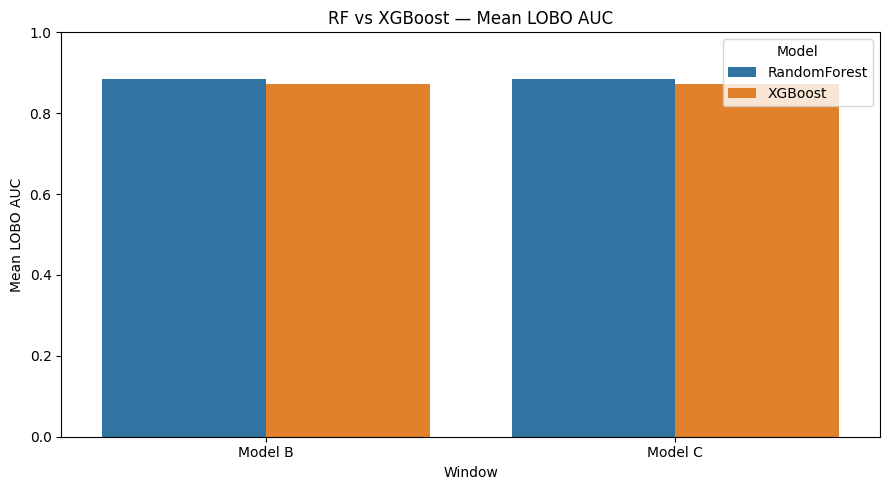

In [6]:
# Algorithm comparison visualization
cmp = pd.concat([result_b["all_results"].assign(Window="Model B"),
                 result_c["all_results"].assign(Window="Model C")], ignore_index=True)
mean_cmp = cmp.groupby(["Window","Model"], as_index=False).AUC.mean()

fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(data=mean_cmp, x="Window", y="AUC", hue="Model", ax=ax)
ax.set_ylim(0,1)
ax.set_ylabel("Mean LOBO AUC")
ax.set_title("RF vs XGBoost — Mean LOBO AUC")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,"model_b_c_algorithm_comparison.png"), dpi=150)
plt.show()

cmp.to_csv(os.path.join(RESULTS_DIR,"model_b_c_lobo_all_results.csv"), index=False)
mean_cmp.to_csv(os.path.join(RESULTS_DIR,"model_b_c_mean_auc_comparison.csv"), index=False)


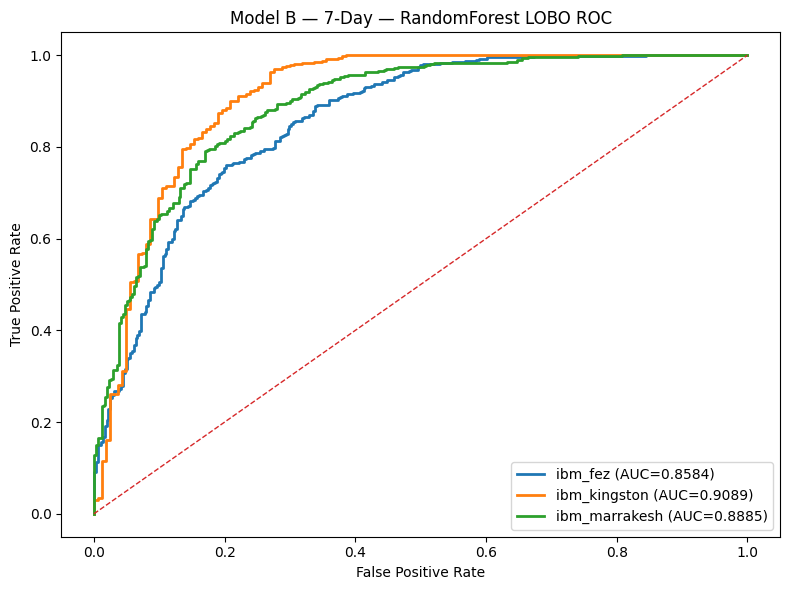

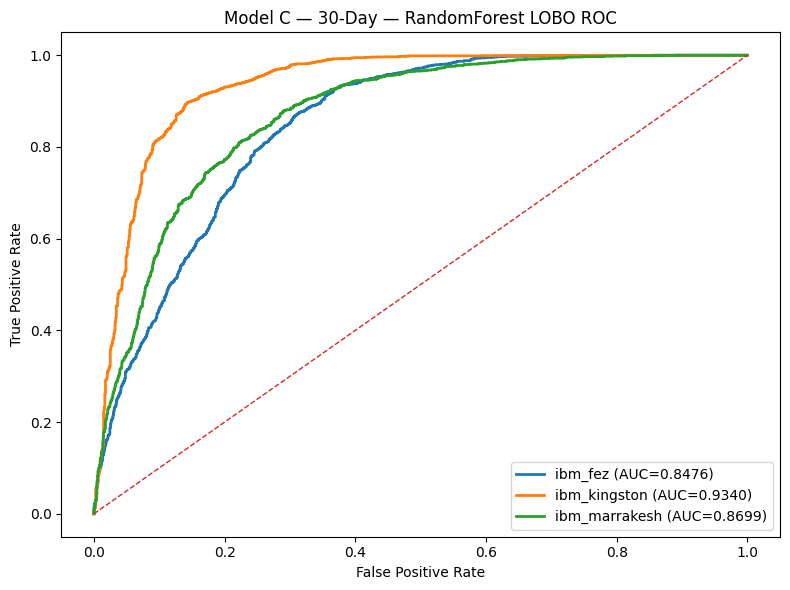

In [7]:
def plot_lobo_roc(result, title, filename):
    fig, ax = plt.subplots(figsize=(8,6))
    for backend, p in result["best_predictions"].items():
        fpr, tpr, _ = roc_curve(p["y_true"], p["y_prob"])
        auc = roc_auc_score(p["y_true"], p["y_prob"])
        ax.plot(fpr, tpr, linewidth=2, label=f"{backend} (AUC={auc:.4f})")
    ax.plot([0,1],[0,1],"--", linewidth=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{title} — {result['best_name']} LOBO ROC")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR,filename), dpi=150)
    plt.show()

plot_lobo_roc(result_b, "Model B — 7-Day", "model_b_selected_lobo_roc.png")
plot_lobo_roc(result_c, "Model C — 30-Day", "model_c_selected_lobo_roc.png")


## Cluster bootstrap 95% CI

The previous notebook used a **2,000-iteration cluster bootstrap**, resampling whole qubit clusters because observations from the same qubit are correlated. fileciteturn11file0L29-L39

In [8]:
def cluster_bootstrap_auc(y, p, clusters, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    d = pd.DataFrame({"y":y, "p":p, "cluster":clusters})
    ids = d.cluster.unique()
    observed = roc_auc_score(y,p)
    vals = []

    for _ in range(n_boot):
        sampled = rng.choice(ids, size=len(ids), replace=True)
        pieces = [d[d.cluster == c] for c in sampled]
        s = pd.concat(pieces, ignore_index=True)
        if s.y.nunique() == 2:
            vals.append(roc_auc_score(s.y,s.p))

    return observed, np.percentile(vals,2.5), np.percentile(vals,97.5)

def bootstrap_result(result, window):
    out=[]
    for backend,p in result["best_predictions"].items():
        obs, lo, hi = cluster_bootstrap_auc(
            p["y_true"], p["y_prob"], p["qubit"], 2000, RANDOM_STATE
        )
        print(f"{backend}: AUC={obs:.4f} 95% CI=[{lo:.4f}, {hi:.4f}]")
        out.append({
            "Window":window, "Model":result["best_name"],
            "Backend":backend, "Observed_AUC":obs,
            "CI_Lower_95":lo, "CI_Upper_95":hi
        })
    return pd.DataFrame(out)

boot = pd.concat([
    bootstrap_result(result_b,"Model B"),
    bootstrap_result(result_c,"Model C")
], ignore_index=True)

boot.to_csv(os.path.join(RESULTS_DIR,"model_b_c_bootstrap_ci.csv"), index=False)


ibm_fez: AUC=0.8584 95% CI=[0.8186, 0.8923]
ibm_kingston: AUC=0.9089 95% CI=[0.8596, 0.9445]
ibm_marrakesh: AUC=0.8885 95% CI=[0.8537, 0.9169]
ibm_fez: AUC=0.8476 95% CI=[0.8136, 0.8763]
ibm_kingston: AUC=0.9340 95% CI=[0.9096, 0.9533]
ibm_marrakesh: AUC=0.8699 95% CI=[0.8428, 0.8933]


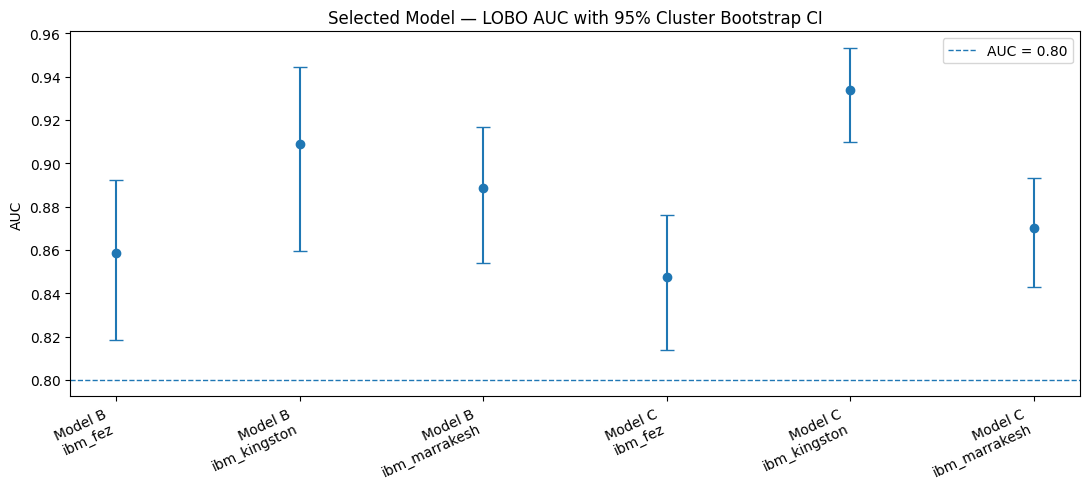

In [9]:
# Bootstrap CI visualization
x = np.arange(len(boot))
y = boot.Observed_AUC.to_numpy()
lo = boot.CI_Lower_95.to_numpy()
hi = boot.CI_Upper_95.to_numpy()

fig, ax = plt.subplots(figsize=(11,5))
ax.errorbar(x, y, yerr=[y-lo, hi-y], fmt="o", capsize=5)
ax.axhline(0.80, linestyle="--", linewidth=1, label="AUC = 0.80")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r.Window}\n{r.Backend}" for r in boot.itertuples()],
    rotation=25, ha="right"
)
ax.set_ylabel("AUC")
ax.set_title("Selected Model — LOBO AUC with 95% Cluster Bootstrap CI")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR,"model_b_c_bootstrap_ci.png"), dpi=150)
plt.show()


In [10]:
def train_final(model_df, algorithm):
    if algorithm == "XGBoost":
        m = XGBClassifier(**XGB_PARAMS)
        params = XGB_PARAMS
    else:
        m = RandomForestClassifier(**RF_PARAMS)
        params = RF_PARAMS
    m.fit(model_df[HIST_FEATURES], model_df.label)
    return m, params

def save_final(model_df, result, label, filename, start, end):
    m, params = train_final(model_df, result["best_name"])
    path = os.path.join(MODELS_DIR, filename)
    with open(path, "wb") as f:
        pickle.dump(m, f)

    lr = result["best_results"]
    meta = {
        "model_name":label,
        "model_file":filename,
        "selected_algorithm":result["best_name"],
        "selection_rule":"highest_mean_LOBO_AUC",
        "training_start":start,
        "training_end":end,
        "calendar_days_in_window":int(raw[
            (raw.snapshot_date >= pd.Timestamp(start)) &
            (raw.snapshot_date <= pd.Timestamp(end))
        ].snapshot_date.nunique()),
        "training_rows":int(len(model_df)),
        "backends":sorted(model_df.backend.unique().tolist()),
        "n_features":len(HIST_FEATURES),
        "features":HIST_FEATURES,
        "label_thresholds":{"T1_us":T1_THRESH,"T2_us":T2_THRESH,"readout_error":RE_THRESH},
        "label_source":"current_session",
        "feature_source":"prior_sessions_only_shift_expand",
        "leakage_status":"NONE_VERIFIED_BY_AUDIT",
        "model_parameters":params,
        "lobo_results":lr.round(6).to_dict(orient="records"),
        "lobo_mean_auc":float(lr.AUC.mean()),
        "lobo_min_auc":float(lr.AUC.min()),
        "trained_on_date":str(date.today())
    }

    meta_path = os.path.join(RESULTS_DIR, filename.replace(".pkl","_metadata.json"))
    with open(meta_path,"w",encoding="utf-8") as f:
        json.dump(meta,f,indent=2)

    print(f"{label}: {result['best_name']} saved -> {path}")
    print(f"Mean LOBO AUC: {meta['lobo_mean_auc']:.4f}")
    return m, meta

model_b, meta_b = save_final(
    df_b, result_b, "Model_B", "model_b_7day.pkl",
    MODEL_B_START, MODEL_B_END
)
model_c, meta_c = save_final(
    df_c, result_c, "Model_C", "model_c_30day.pkl",
    MODEL_C_START, MODEL_C_END
)


Model_B: RandomForest saved -> D:\Downloads\uday projects\ibm_quantum\models\model_b_7day.pkl
Mean LOBO AUC: 0.8853
Model_C: RandomForest saved -> D:\Downloads\uday projects\ibm_quantum\models\model_c_30day.pkl
Mean LOBO AUC: 0.8838


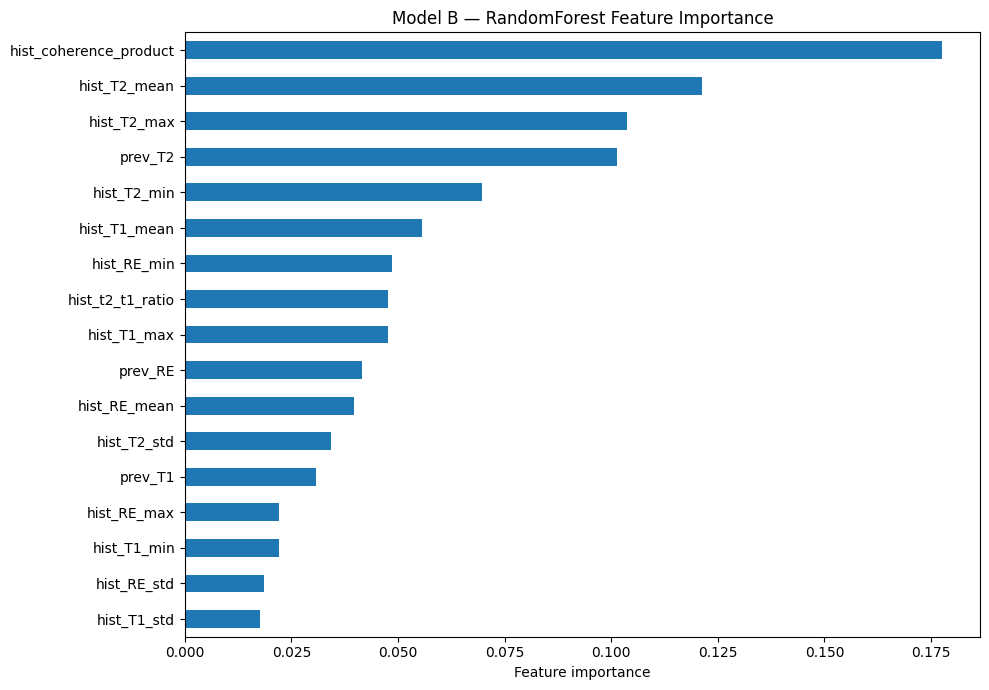

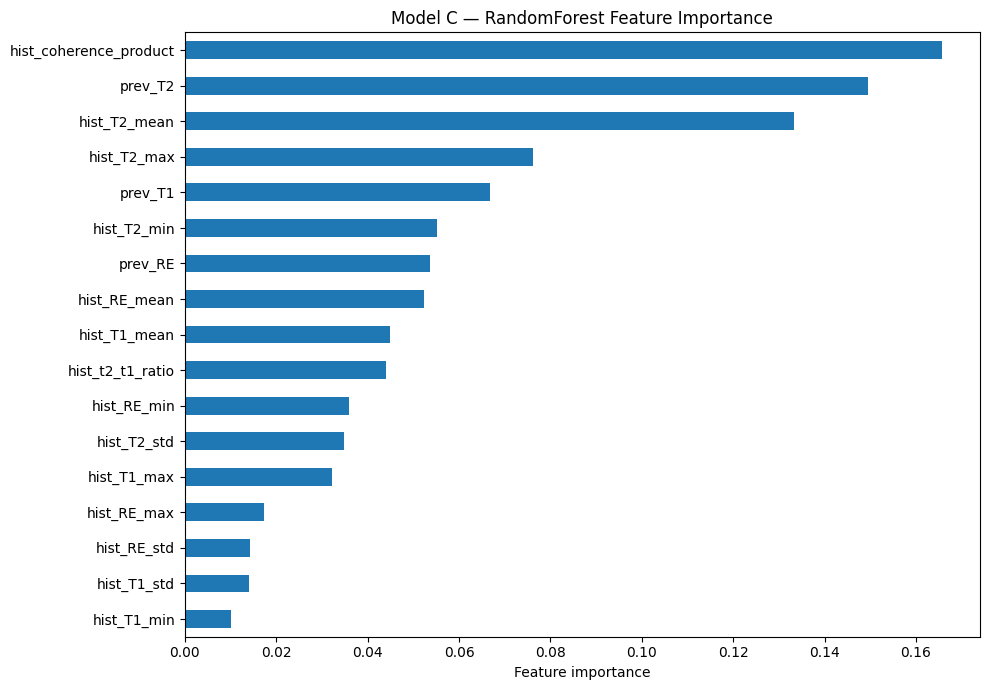

,Model,Window,Selected_Algorithm,Rows,Mean_LOBO_AUC,Min_LOBO_AUC
0,Model B,2026-07-13 → 2026-07-19,RandomForest,2330,0.885259,0.858364
1,Model C,2026-07-13 → 2026-08-11,RandomForest,13048,0.883847,0.847618


In [11]:
# Final feature-importance visualizations
def feature_importance(model, title, filename):
    s = pd.Series(model.feature_importances_, index=HIST_FEATURES).sort_values()
    fig, ax = plt.subplots(figsize=(10,7))
    s.plot(kind="barh", ax=ax)
    ax.set_xlabel("Feature importance")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR,filename), dpi=150)
    plt.show()
    return s

imp_b = feature_importance(model_b, f"Model B — {meta_b['selected_algorithm']} Feature Importance", "model_b_feature_importance.png")
imp_c = feature_importance(model_c, f"Model C — {meta_c['selected_algorithm']} Feature Importance", "model_c_feature_importance.png")

imp_b.to_csv(os.path.join(RESULTS_DIR,"model_b_feature_importance.csv"))
imp_c.to_csv(os.path.join(RESULTS_DIR,"model_c_feature_importance.csv"))

summary = pd.DataFrame([
    {
        "Model":"Model B",
        "Window":f"{MODEL_B_START} → {MODEL_B_END}",
        "Selected_Algorithm":meta_b["selected_algorithm"],
        "Rows":meta_b["training_rows"],
        "Mean_LOBO_AUC":meta_b["lobo_mean_auc"],
        "Min_LOBO_AUC":meta_b["lobo_min_auc"]
    },
    {
        "Model":"Model C",
        "Window":f"{MODEL_C_START} → {MODEL_C_END}",
        "Selected_Algorithm":meta_c["selected_algorithm"],
        "Rows":meta_c["training_rows"],
        "Mean_LOBO_AUC":meta_c["lobo_mean_auc"],
        "Min_LOBO_AUC":meta_c["lobo_min_auc"]
    }
])
summary


## Final outputs

The notebook saves:

- `models/model_b_7day.pkl` — **winning B algorithm**
- `models/model_c_30day.pkl` — **winning C algorithm**
- metadata JSON for both
- complete RF/XGBoost LOBO results
- mean-AUC comparison
- 2,000-iteration cluster-bootstrap CIs
- LOBO ROC figures
- algorithm comparison figure
- feature-importance figures

The saved B/C models are therefore **not forced to Random Forest**. Each window independently trains RF and XGBoost, evaluates both with the same LOBO procedure, selects the higher mean-AUC model, and only then trains that winner on the complete window for deployment.